In [2]:
import pandas as pd
from IPython.display import display

# 1) Reload the four columns we care about
csv_path = "/Users/guest08/Downloads/pp-complete.csv"
usecols = [1, 2, 12, 13]
names  = ["Price", "Date of Transfer", "District", "County"]

df = pd.read_csv(
    csv_path,
    header=None,
    usecols=usecols,
    names=names,
    parse_dates=["Date of Transfer"],
    dayfirst=True
)

# 2) Normalize text
df["District"] = df["District"].str.strip().str.title()
df["County"]   = df["County"].str.strip().str.upper()

# 3) Filter to Greater Manchester
df_gm = df[df["County"] == "GREATER MANCHESTER"].copy()
print("After GM filter:", len(df_gm), "rows")

# 4) Convert Price → numeric & drop bad rows
df_gm["Price"] = pd.to_numeric(df_gm["Price"], errors="coerce")
df_gm = df_gm.dropna(subset=["Price"])
df_gm["Price"] = df_gm["Price"].astype(int)
print("After cleaning Price:", len(df_gm), "rows")

# 5) Quick peek at clean GM data
display(df_gm.head())

# 6) Top 20 sales by value
print("Top 20 Manchester sales by Price:")
display(df_gm.nlargest(20, "Price"))

/var/folders/z3/dsbdx20d08j9t4s0ldz27_b80000gp/T/ipykernel_26247/3150800786.py:9: UserWarning: Parsing dates in %Y-%m-%d %H:%M format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df = pd.read_csv(


After GM filter: 1337005 rows
After cleaning Price: 1337005 rows


,Price,Date of Transfer,District,County
74,51500,1995-06-30,Manchester,GREATER MANCHESTER
106,37950,1995-05-05,Tameside,GREATER MANCHESTER
113,76500,1995-03-22,Bury,GREATER MANCHESTER
135,112500,1995-11-24,Stockport,GREATER MANCHESTER
140,35000,1995-11-30,Manchester,GREATER MANCHESTER


Top 20 Manchester sales by Price:


,Price,Date of Transfer,District,County
26588024,292000000,2021-12-17,Manchester,GREATER MANCHESTER
22282297,107086856,2017-02-17,Manchester,GREATER MANCHESTER
26646817,106772324,2021-10-14,Rochdale,GREATER MANCHESTER
27019205,106772324,2021-10-21,Rochdale,GREATER MANCHESTER
23674593,103033044,2018-01-05,Manchester,GREATER MANCHESTER
22090444,95814932,2017-08-02,Salford,GREATER MANCHESTER
25338198,93395000,2020-04-22,Wigan,GREATER MANCHESTER
25361948,93395000,2020-04-22,Stockport,GREATER MANCHESTER
22098548,93100000,2017-12-22,Manchester,GREATER MANCHESTER
26092634,90455050,2021-03-26,Manchester,GREATER MANCHESTER


Average House Price by Borough:


District
Trafford      250568.808197
Stockport     191158.308596
Manchester    175903.885981
Salford       156144.809438
Bury          140789.608920
Bolton        128610.062197
Rochdale      126630.503867
Wigan         125106.534930
Tameside      121467.656366
Oldham        117476.421361
Name: AvgPrice, dtype: float64

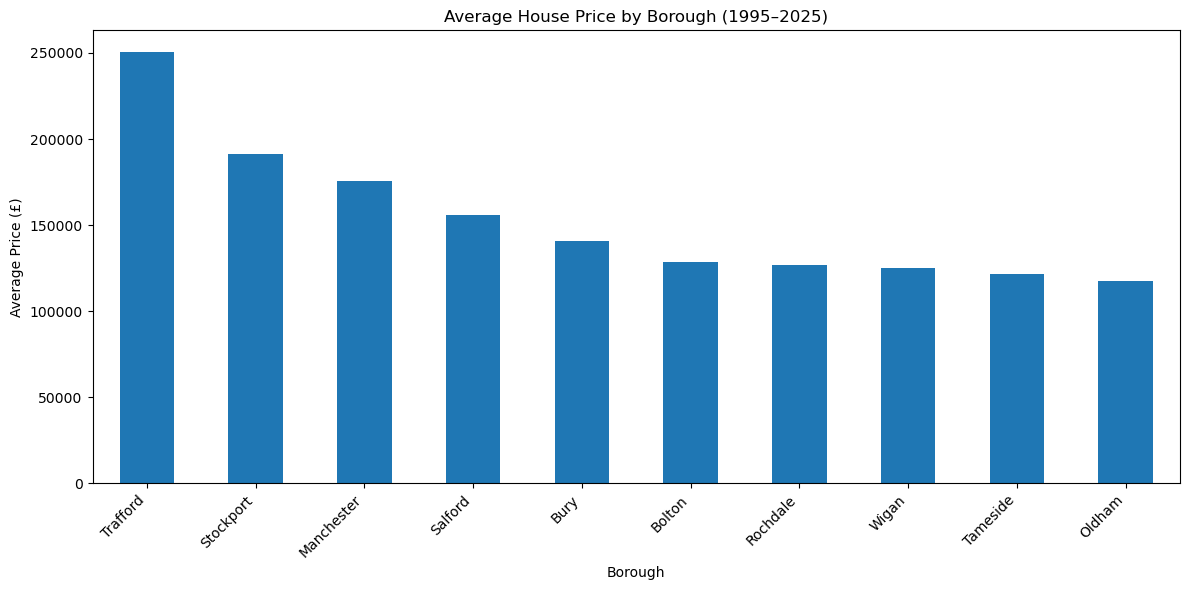


Average House Price by Year:


Year
1995     50113.276907
1996     51130.687097
1997     55085.182120
1998     57750.055179
1999     62188.973422
2000     66495.044779
2001     73039.522509
2002     85201.583087
2003    100252.688812
2004    121813.329994
2005    134560.841231
2006    146641.788862
2007    156016.163767
2008    150852.839154
2009    147321.260368
2010    152942.772388
2011    149168.340720
2012    151553.956440
2013    158571.819298
2014    183589.776270
2015    186339.207250
2016    201534.430113
2017    228939.635496
2018    235996.626911
2019    231162.083765
2020    252353.857599
2021    278522.177169
2022    286376.898861
2023    286152.330917
2024    270907.232502
2025    253845.142194
Name: AvgPrice, dtype: float64

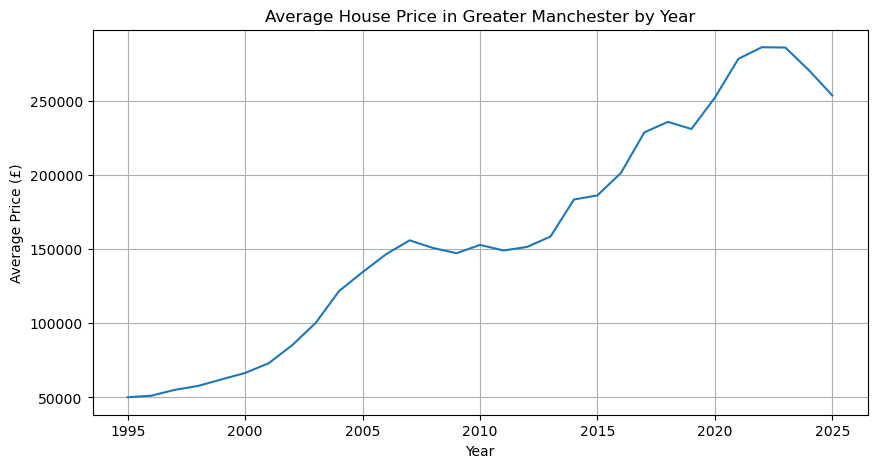

In [3]:
import matplotlib.pyplot as plt
from IPython.display import display

# 1) Average price by borough
avg_by_borough = (
    df_gm
    .groupby("District")["Price"]
    .mean()
    .sort_values(ascending=False)
    .rename("AvgPrice")
)
print("Average House Price by Borough:")
display(avg_by_borough)

# Bar plot of average price by borough
plt.figure(figsize=(12, 6))
avg_by_borough.plot(kind="bar")
plt.title("Average House Price by Borough (1995–2025)")
plt.xlabel("Borough")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2) Average price by year
df_gm["Year"] = df_gm["Date of Transfer"].dt.year
avg_by_year = (
    df_gm
    .groupby("Year")["Price"]
    .mean()
    .sort_index()
    .rename("AvgPrice")
)
print("\nAverage House Price by Year:")
display(avg_by_year)

# Line plot of average price over time
plt.figure(figsize=(10, 5))
plt.plot(avg_by_year.index, avg_by_year.values)
plt.title("Average House Price in Greater Manchester by Year")
plt.xlabel("Year")
plt.ylabel("Average Price (£)")
plt.grid(True)
plt.show()

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder

# 1) Compute 0.5% and 99.5% quantiles of Price
lower, upper = df_gm["Price"].quantile([0.005, 0.995])
print(f"Trimming prices below £{lower:,.0f} and above £{upper:,.0f}")

# 2) Subset to the central 99%
df_trim = df_gm[(df_gm["Price"] >= lower) & (df_gm["Price"] <= upper)].copy()
print("Rows after trimming extremes:", len(df_trim))

# 3) Feature engineering on trimmed data
df_trim["Year"]  = df_trim["Date of Transfer"].dt.year
df_trim["Month"] = df_trim["Date of Transfer"].dt.month

# One‑hot encode District
ohe = OneHotEncoder(sparse_output=False, drop="first")
district_encoded = ohe.fit_transform(df_trim[["District"]])
district_cols    = ohe.get_feature_names_out(["District"])
df_ohe           = pd.DataFrame(district_encoded, columns=district_cols, index=df_trim.index)

# Combine Year, Month and borough dummies
X = pd.concat([df_trim[["Year", "Month"]], df_ohe], axis=1)
y = df_trim["Price"]

# 4) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5) Fit Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# 6) Predict & evaluate
y_pred = lr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"Trimmed Linear Regression MAE: £{mae:,.0f}")
print(f"Trimmed Linear Regression RMSE: £{rmse:,.0f}")

Trimming prices below £8,500 and above £925,000
Rows after trimming extremes: 1323891
Trimmed Linear Regression MAE: £60,090
Trimmed Linear Regression RMSE: £90,556


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Prepare X and y (using the same df_trim and ohe from your trimmed run)
#    If you’ve already built X_train, X_test, y_train, y_test above, you can reuse them.
#    Otherwise, rerun the feature‑engineering block on df_trim to get X_train/test.

# 2) Initialize and fit the Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,        # you can tune this up/down
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 3) Predict and evaluate
y_rf_pred = rf.predict(X_test)
rf_mae  = mean_absolute_error(y_test,  y_rf_pred)
rf_rmse = mean_squared_error(y_test, y_rf_pred, squared=False)

print(f"Random Forest MAE:  £{rf_mae:,.0f}")
print(f"Random Forest RMSE: £{rf_rmse:,.0f}")

Random Forest MAE:  £57,436
Random Forest RMSE: £88,282


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Top 10 Feature Importances:
Year                   0.755559
District_Trafford      0.119650
District_Stockport     0.078423
District_Manchester    0.017748
Month                  0.014979
District_Bury          0.006633
District_Salford       0.004947
District_Oldham        0.000687
District_Wigan         0.000554
District_Tameside      0.000510
dtype: float64


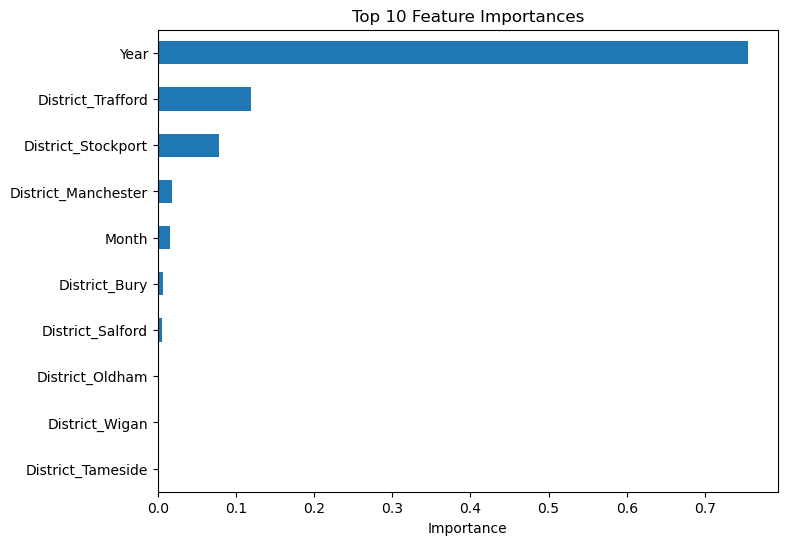

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming rf is your trained RandomForestRegressor
# and X_train is the DataFrame you used to fit it

# 1) Grab importances and label them
importances = rf.feature_importances_
features    = X_train.columns
feat_imp    = pd.Series(importances, index=features).sort_values(ascending=False)

# 2) Print top 10
print("Top 10 Feature Importances:")
print(feat_imp.head(10))

# 3) Bar chart of top 10
plt.figure(figsize=(8, 6))
feat_imp.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [7]:
import pandas as pd

# 1) Reload the minimal set of columns we need:
#    – 1: Price
#    – 2: Date of Transfer
#    – 4: Property Type
#    – 5: Old/New
#    – 12: District
#    – 13: County
csv_path = "/Users/guest08/Downloads/pp-complete.csv"
usecols   = [1, 2, 4, 5, 12, 13]
names     = ["Price", "Date of Transfer", "Property Type", "Old/New", "District", "County"]

df = pd.read_csv(
    csv_path,
    header=None,
    usecols=usecols,
    names=names,
    parse_dates=["Date of Transfer"],
    dayfirst=True,
    infer_datetime_format=True
)

# 2) Normalize and filter to Greater Manchester
df["District"] = df["District"].str.strip().str.title()
df["County"]   = df["County"].str.strip().str.upper()
df = df[df["County"] == "GREATER MANCHESTER"].copy()

# 3) Convert Price to numeric and drop bad rows
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df = df.dropna(subset=["Price"])
df["Price"] = df["Price"].astype(int)

# 4) Trim the outer 0.5% of prices
low, high = df["Price"].quantile([0.005, 0.995])
df_trim = df[(df["Price"] >= low) & (df["Price"] <= high)].copy()
print(f"Trimmed to {len(df_trim):,} rows between £{low:,.0f}–£{high:,.0f}")

# 5) Feature engineering on df_trim:
df_trim["Year"]  = df_trim["Date of Transfer"].dt.year
df_trim["Month"] = df_trim["Date of Transfer"].dt.month

#  - Is it a new build?
df_trim["IsNew"] = (df_trim["Old/New"] == "Y").astype(int)

#  - One‑hot encode Property Type
prop_dummies = pd.get_dummies(
    df_trim["Property Type"], 
    prefix="PropType", 
    drop_first=True
)
df_trim = pd.concat([df_trim, prop_dummies], axis=1)

# 6) Drop raw columns you’ve encoded
df_trim = df_trim.drop(columns=["Old/New", "Property Type"])

print("New columns:", ["Year","Month","IsNew"] + list(prop_dummies.columns))
df_trim.head()

/var/folders/z3/dsbdx20d08j9t4s0ldz27_b80000gp/T/ipykernel_26247/630572280.py:14: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
/var/folders/z3/dsbdx20d08j9t4s0ldz27_b80000gp/T/ipykernel_26247/630572280.py:14: UserWarning: Parsing dates in %Y-%m-%d %H:%M format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df = pd.read_csv(


Trimmed to 1,323,891 rows between £8,500–£925,000
New columns: ['Year', 'Month', 'IsNew', 'PropType_F', 'PropType_O', 'PropType_S', 'PropType_T']


,Price,Date of Transfer,District,County,Year,Month,IsNew,PropType_F,PropType_O,PropType_S,PropType_T
74,51500,1995-06-30,Manchester,GREATER MANCHESTER,1995,6,0,False,False,False,True
106,37950,1995-05-05,Tameside,GREATER MANCHESTER,1995,5,0,False,False,False,True
113,76500,1995-03-22,Bury,GREATER MANCHESTER,1995,3,0,False,False,True,False
135,112500,1995-11-24,Stockport,GREATER MANCHESTER,1995,11,1,False,False,False,False
140,35000,1995-11-30,Manchester,GREATER MANCHESTER,1995,11,0,False,False,True,False


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder

# One‑hot encode District
ohe = OneHotEncoder(sparse_output=False, drop="first")
dist_enc = ohe.fit_transform(df_trim[["District"]])
dist_cols = ohe.get_feature_names_out(["District"])
df_dist   = pd.DataFrame(dist_enc, columns=dist_cols, index=df_trim.index)

# Build X and y
X = pd.concat([
    df_trim[["Year", "Month", "IsNew"]],
    prop_dummies,
    df_dist
], axis=1)
y = df_trim["Price"]

# Split, fit and evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, y_pred)))
print("RMSE:", round(mean_squared_error(y_test, y_pred, squared=False)))

MAE: 51920
RMSE: 79061


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1) Prepare district dummies (reuse df_trim from before)
ohe = OneHotEncoder(sparse_output=False, drop="first")
dist_enc = ohe.fit_transform(df_trim[["District"]])
dist_cols = ohe.get_feature_names_out(["District"])
df_dist   = pd.DataFrame(dist_enc, columns=dist_cols, index=df_trim.index)

# 2) Combine all features
X = pd.concat([
    df_trim[["Year", "Month", "IsNew"]],
    df_trim.filter(like="PropType_"),  # your prop dummies
    df_dist
], axis=1)
y = df_trim["Price"]

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) Fit Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 5) Predict & evaluate
y_pred = rf.predict(X_test)
print(f"RF MAE:  £{mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RF RMSE: £{mean_squared_error(y_test, y_pred, squared=False):,.0f}")

RF MAE:  £43,508
RF RMSE: £72,107


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── 0) Reload minimal columns and filter/clean ──
csv_path = "/Users/guest08/Downloads/pp-complete.csv"
usecols   = [1, 2, 3, 4, 5, 12, 13]  # include Postcode idx 3 if you ever need it
names     = ["Price","Date of Transfer","Postcode","Property Type","Old/New","District","County"]

df = pd.read_csv(
    csv_path,
    header=None,
    usecols=usecols,
    names=names,
    parse_dates=["Date of Transfer"],
    dayfirst=True
)

# Normalize text and filter to GM
df["District"] = df["District"].str.strip().str.title()
df["County"]   = df["County"].str.strip().str.upper()
df = df[df["County"] == "GREATER MANCHESTER"].copy()

# Convert Price to int and drop bad
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df = df.dropna(subset=["Price"])
df["Price"] = df["Price"].astype(int)

# Trim outer 0.5%
low, high = df["Price"].quantile([0.005, 0.995])
df_trim = df[(df["Price"] >= low) & (df["Price"] <= high)].copy()

# ── 1) Feature engineering ──
# Date features
df_trim["Year"]  = df_trim["Date of Transfer"].dt.year
df_trim["Month"] = df_trim["Date of Transfer"].dt.month

# Is it a new build?
df_trim["IsNew"] = (df_trim["Old/New"] == "Y").astype(int)

# One‑hot Property Type
prop_dummies = pd.get_dummies(
    df_trim["Property Type"],
    prefix="PropType",
    drop_first=True
)
df_trim = pd.concat([df_trim, prop_dummies], axis=1)

# Proxy distance to centre by borough
dist_dict = {
    "Manchester": 0.0, "Salford": 1.3, "Trafford": 4.5, "Stockport": 8.2,
    "Tameside": 6.8, "Oldham": 9.6, "Bury": 8.4, "Rochdale": 13.2,
    "Bolton": 13.9, "Wigan": 18.2
}
df_trim["DistToCenter"] = df_trim["District"].map(dist_dict)

# ── 2) One‑hot Borough ──
ohe = OneHotEncoder(sparse_output=False, drop="first")
dist_enc = ohe.fit_transform(df_trim[["District"]])
dist_cols = ohe.get_feature_names_out(["District"])
df_dist   = pd.DataFrame(dist_enc, columns=dist_cols, index=df_trim.index)

# ── 3) Build X, y and split ──
X = pd.concat([
    df_trim[["Year","Month","IsNew","DistToCenter"]],
    prop_dummies,
    df_dist
], axis=1)
y = df_trim["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 4) Train & evaluate Random Forest ──
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"RF + All Features MAE:  £{mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RF + All Features RMSE: £{mean_squared_error(y_test, y_pred, squared=False):,.0f}")

/var/folders/z3/dsbdx20d08j9t4s0ldz27_b80000gp/T/ipykernel_26602/2419395131.py:12: UserWarning: Parsing dates in %Y-%m-%d %H:%M format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df = pd.read_csv(


RF + All Features MAE:  £43,480
RF + All Features RMSE: £72,075


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [3]:
from sklearn.model_selection import RandomizedSearchCV

# 1) Define the parameter grid
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2", 0.8]
}

# 2) Set up RandomizedSearchCV
rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

# 3) Run the search on your training data
rs.fit(X_train, y_train)

print("Best parameters:", rs.best_params_)

# 4) Evaluate the best model
best_rf = rs.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("Tuned RF MAE:  £", round(mean_absolute_error(y_test, y_pred_tuned)))
print("Tuned RF RMSE: £", round(mean_squared_error(y_test, y_pred_tuned, squared=False)))

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'n_estimators': 100, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 15}
Tuned RF MAE:  £ 43479
Tuned RF RMSE: £ 72017


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1) Recompute avg_by_year if you don’t already have it:
#    (This assumes df_gm is in memory.)
df_gm["Year"] = df_gm["Date of Transfer"].dt.year
avg_by_year = df_gm.groupby("Year")["Price"].mean().sort_index().reset_index()

# 2) Fit a linear trend
X = avg_by_year[["Year"]]
y = avg_by_year["Price"]
model = LinearRegression().fit(X, y)

# 3) Create future years and predict
future_years = pd.DataFrame({"Year": np.arange(2026, 2031)})
future_years["PredictedPrice"] = model.predict(future_years)

# 4) Combine with historicals for plotting
all_years = pd.concat([
    avg_by_year.rename(columns={"Price":"AvgPrice"}),
    future_years.rename(columns={"PredictedPrice":"AvgPrice"})
], ignore_index=True)

# 5) Plot
plt.figure(figsize=(10,5))
plt.plot(avg_by_year["Year"], avg_by_year["Price"], label="Historical")
plt.plot(future_years["Year"], future_years["PredictedPrice"], 
         linestyle="--", marker="o", label="Forecast")
plt.title("Greater Manchester Avg House Price: Historical & Forecast")
plt.xlabel("Year")
plt.ylabel("Price (£)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gm_price_forecast.png", dpi=300)
plt.show()

# 6) Table of forecasts
print(future_years.set_index("Year"))

NameError: name 'df_gm' is not defined